# Variational Autoencoder — Animals-10 Dataset

This notebook trains a **convolutional VAE** on the Animals-10 dataset, which contains ~27,000 images across 10 animal classes.  
After training, new images can be **generated** by sampling from the learned latent space.

### Notebook structure
1. Setup & imports  
2. Dataset exploration  
3. Data pipeline  
4. VAE architecture  
4b. cVAE architecture  
5. Loss function (ELBO)  
6. MLflow experiment setup  
7. Training  
8. Loss curves  
9. Image generation  
10. Reconstruction  
11. Latent space interpolation  
12. Evaluation — IS & FID

## 1. Setup & imports

In [1]:
import os
import random

import mlflow
import mlflow.pytorch
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from PIL import Image
from tqdm.notebook import tqdm

# Fix seeds for reproducibility so results are comparable across runs
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Select the best available compute device:
# MPS = Apple Silicon GPU | CUDA = NVIDIA GPU | CPU = fallback
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print(f"Device : {DEVICE}")
print(f"PyTorch: {torch.__version__}")
print(f"MLflow : {mlflow.__version__}")

Device : cpu
PyTorch: 2.2.2
MLflow : 3.12.0


## 2. Dataset exploration

**Animals-10** contains color images from 10 classes (originally labeled in Italian).  
We count images per class and display a visual sample before any preprocessing.

In [2]:
# Italian -> English label mapping
LABEL_MAP = {
    "cane":       "dog",
    "cavallo":    "horse",
    "elefante":   "elephant",
    "farfalla":   "butterfly",
    "gallina":    "chicken",
    "gatto":      "cat",
    "mucca":      "cow",
    "pecora":     "sheep",
    "ragno":      "spider",
    "scoiattolo": "squirrel",
}

DATA_DIR = "archive/raw-img"

# Count images per class
class_counts = {}
for class_name in sorted(os.listdir(DATA_DIR)):
    class_path = os.path.join(DATA_DIR, class_name)
    if not os.path.isdir(class_path):
        continue
    files = [f for f in os.listdir(class_path)
             if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    class_counts[class_name] = len(files)

total = sum(class_counts.values())
print(f"Total images: {total}\n")
print(f"{'Class':<12} {'English':<12} {'Images':>8}")
print("-" * 35)
for cls, count in sorted(class_counts.items(), key=lambda x: -x[1]):
    print(f"{cls:<12} {LABEL_MAP.get(cls, cls):<12} {count:>8}")

Total images: 26179

Class        English        Images
-----------------------------------
cane         dog              4863
ragno        spider           4821
gallina      chicken          3098
cavallo      horse            2623
farfalla     butterfly        2112
mucca        cow              1866
scoiattolo   squirrel         1862
pecora       sheep            1820
gatto        cat              1668
elefante     elephant         1446


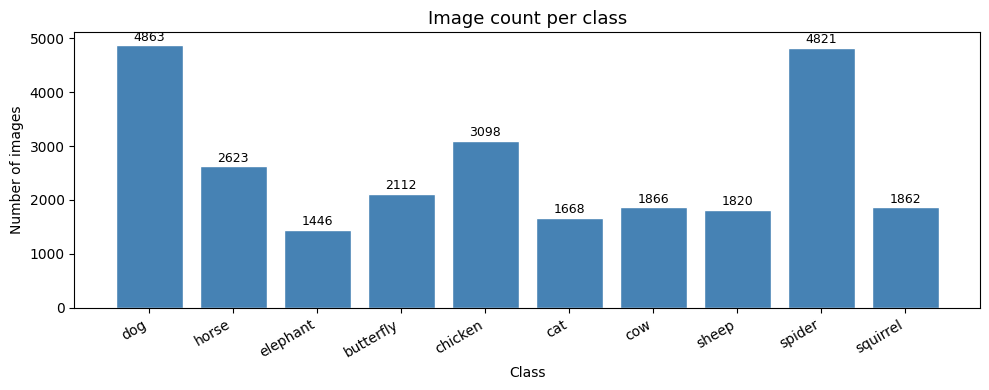

In [3]:
# Bar chart of class distribution
fig, ax = plt.subplots(figsize=(10, 4))
classes = list(class_counts.keys())
counts  = list(class_counts.values())
labels  = [LABEL_MAP.get(c, c) for c in classes]

bars = ax.bar(labels, counts, color="steelblue", edgecolor="white")
ax.set_title("Image count per class", fontsize=13)
ax.set_xlabel("Class")
ax.set_ylabel("Number of images")

for bar, v in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
            str(v), ha="center", va="bottom", fontsize=9)

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

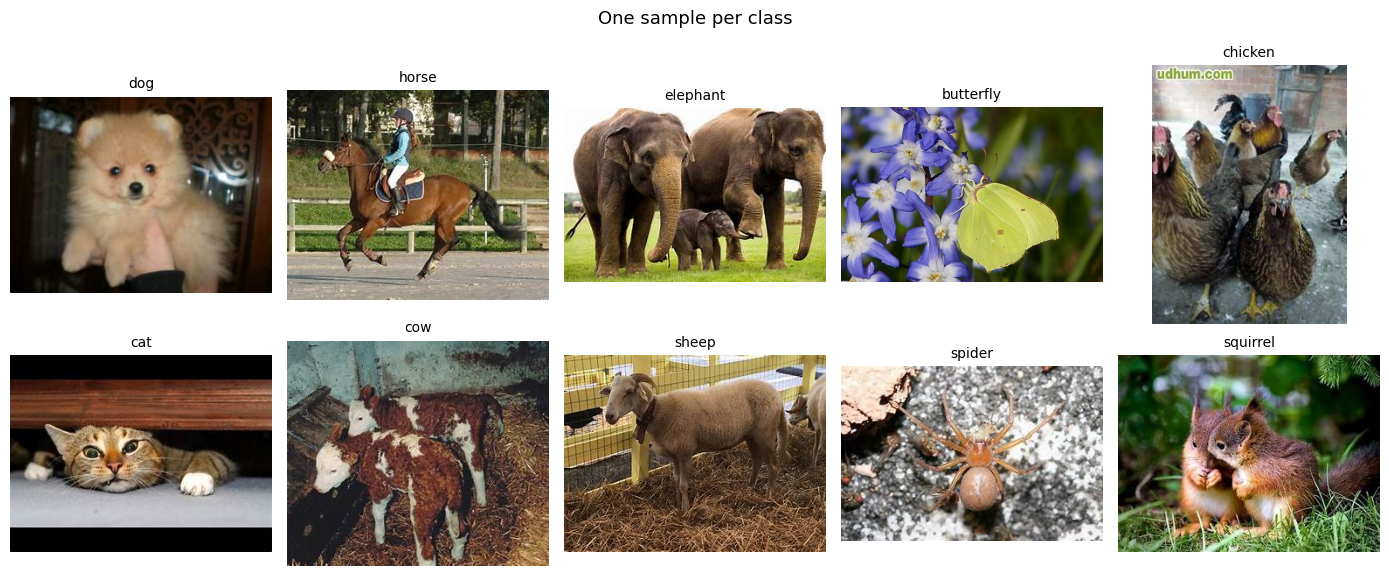

In [4]:
# Display one random image per class
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle("One sample per class", fontsize=13)

for ax, (cls, label) in zip(axes.flat, LABEL_MAP.items()):
    class_path = os.path.join(DATA_DIR, cls)
    files = [f for f in os.listdir(class_path)
             if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    img_path = os.path.join(class_path, random.choice(files))
    img = Image.open(img_path).convert("RGB")
    ax.imshow(img)
    ax.set_title(label, fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 3. Data pipeline

`AnimalsDataset` loads images lazily from disk (`__getitem__`), applying:
- **Resize** to 64×64 px — standard resolution for VAE experiments
- **ToTensor** — converts PIL Image (uint8 [0, 255]) to float tensor [0, 1]
- **Normalize** — shifts to [-1, 1], matching the decoder's `Tanh` activation

In [5]:
IMG_SIZE = 64  # spatial resolution (square)

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),                   # [0, 1]
    transforms.Normalize([0.5]*3, [0.5]*3),  # -> [-1, 1]
])


class AnimalsDataset(Dataset):
    """
    Animals-10 image dataset.

    Walks `root_dir` and collects all .jpg/.jpeg/.png files found
    in first-level subdirectories (one subdirectory per class).

    Args:
        root_dir  : Path to the dataset root folder.
        transform : torchvision transform pipeline.
    """

    def __init__(self, root_dir: str, transform=transform):
        self.transform = transform
        self.samples: list[str] = []

        for class_name in os.listdir(root_dir):
            class_path = os.path.join(root_dir, class_name)
            if not os.path.isdir(class_path):
                continue
            for fname in os.listdir(class_path):
                if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                    self.samples.append(os.path.join(class_path, fname))

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int) -> torch.Tensor:
        img = Image.open(self.samples[idx]).convert("RGB")
        return self.transform(img)


BATCH_SIZE = 64

dataset = AnimalsDataset(DATA_DIR)
loader  = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,    # 0 = load in main process (required when class is defined in notebook)
    pin_memory=False,
)

print(f"Total images  : {len(dataset)}")
print(f"Batches/epoch : {len(loader)}")
print(f"Batch shape   : {next(iter(loader)).shape}")

Total images  : 26179
Batches/epoch : 410
Batch shape   : torch.Size([64, 3, 64, 64])


## 4. VAE architecture

A **Variational Autoencoder** has three components:

```
Image x ──► Encoder ──► μ, log σ² ──► z = μ + σ·ε  ──► Decoder ──► x̂
                         (posterior          (reparameterization:
                         q(z|x) params)       ε ~ N(0, I))
```

| Component | Layers | Output |
|---|---|---|
| **Encoder** | 4× Conv2d + BN + LeakyReLU | μ and log σ² ∈ ℝ¹²⁸ |
| **Reparameterization** | z = μ + σ·ε | z ∈ ℝ¹²⁸ |
| **Decoder** | FC + 4× ConvTranspose2d + BN + ReLU | x̂ ∈ [−1,1]³ˣ⁶⁴ˣ⁶⁴ |

The **reparameterization trick** is what makes the stochastic sampling differentiable: instead of sampling `z ~ q(z|x)` directly, we sample `ε ~ N(0, I)` and compute `z = μ + σ·ε`, so gradients flow through μ and σ during backprop.

In [6]:
LATENT_DIM = 128  # dimensionality of the latent space


class Encoder(nn.Module):
    """
    Convolutional encoder: maps a 3×64×64 image to the parameters
    (μ, log σ²) of a Gaussian distribution in latent space.

    Each conv block uses stride=2 to halve the spatial resolution
    (learnable downsampling, equivalent to Conv + MaxPool).
    """

    def __init__(self, latent_dim: int = LATENT_DIM):
        super().__init__()
        self.conv = nn.Sequential(
            # 3 × 64 × 64  ->  32 × 32 × 32
            nn.Conv2d(3,   32,  4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2),

            # 32 × 32 × 32  ->  64 × 16 × 16
            nn.Conv2d(32,  64,  4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),

            # 64 × 16 × 16  ->  128 × 8 × 8
            nn.Conv2d(64,  128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            # 128 × 8 × 8  ->  256 × 4 × 4
            nn.Conv2d(128, 256, 4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
        )
        flat = 256 * 4 * 4
        self.fc_mu     = nn.Linear(flat, latent_dim)
        self.fc_logvar = nn.Linear(flat, latent_dim)

    def forward(self, x: torch.Tensor):
        h = self.conv(x).view(x.size(0), -1)  # flatten: (B, 256*4*4)
        return self.fc_mu(h), self.fc_logvar(h)


class Decoder(nn.Module):
    """
    Convolutional decoder: maps a latent vector z ∈ ℝ^{latent_dim}
    back to a 3×64×64 image in the range [-1, 1].

    ConvTranspose2d with stride=2 doubles the spatial resolution at
    each step — the mirror image of the encoder.
    """

    def __init__(self, latent_dim: int = LATENT_DIM):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 256 * 4 * 4)
        self.deconv = nn.Sequential(
            # 256 × 4 × 4  ->  128 × 8 × 8
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            # 128 × 8 × 8  ->  64 × 16 × 16
            nn.ConvTranspose2d(128, 64,  4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            # 64 × 16 × 16  ->  32 × 32 × 32
            nn.ConvTranspose2d(64,  32,  4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            # 32 × 32 × 32  ->  3 × 64 × 64
            nn.ConvTranspose2d(32,  3,   4, stride=2, padding=1),
            nn.Tanh(),  # output in [-1, 1], matching data normalization
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        h = self.fc(z).view(z.size(0), 256, 4, 4)  # reshape: (B, 256, 4, 4)
        return self.deconv(h)


class VAE(nn.Module):
    """
    Full Variational Autoencoder.

    `reparameterize` implements the reparameterization trick:
        z = μ + σ·ε,  ε ~ N(0, I)
    This keeps gradients flowing through the encoder during backprop
    because ε is sampled independently from the model parameters.
    During eval mode, returns μ directly (no noise).
    """

    def __init__(self, latent_dim: int = LATENT_DIM):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def reparameterize(self, mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
        if self.training:
            std = torch.exp(0.5 * logvar)  # σ = exp(0.5 · log σ²)
            eps = torch.randn_like(std)     # ε ~ N(0, I)
            return mu + eps * std
        return mu

    def forward(self, x: torch.Tensor):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z)
        return recon, mu, logvar

    @torch.no_grad()
    def generate(self, n: int) -> torch.Tensor:
        """Generate `n` images by sampling z ~ N(0, I) directly."""
        z = torch.randn(n, self.encoder.fc_mu.out_features).to(
            next(self.parameters()).device
        )
        return self.decoder(z)


model = VAE(latent_dim=LATENT_DIM).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {train_params:,}")
print(model)

Total parameters    : 2,958,659
Trainable parameters: 2,958,659
VAE(
  (encoder): Encoder(
    (conv): Sequential(
      (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.2)
      (3): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): LeakyReLU(negative_slope=0.2)
      (6): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (8): LeakyReLU(negative_slope=0.2)
      (9): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (10): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (11): LeakyReLU(negative_slope=0.2)
    )
    (fc_mu): Linear(in_features=4096,

## 4b. cVAE architecture

The **Conditional VAE** extends the VAE by conditioning both encoder and decoder on the class label `y`:

```
Image x ──► ConditionalEncoder ──► μ, log σ²  ──► z = μ + σ·ε ──► ConditionalDecoder ──► x̂
                      ↑                                                       ↑
                  embed(y)                                                embed(y)
```

The class label is projected to a dense **embedding vector** (`EMBED_DIM=64`) and concatenated:

| Where | How |
|---|---|
| **Encoder** | `cat([conv_features, embed(y)])` before μ / log σ² heads |
| **Decoder** | `cat([z, embed(y)])` before the FC projection |

At inference, `CVAE.generate(y)` samples `z ~ N(0, I)` and decodes with the target class — enabling class-guided generation.

In [ ]:
from model import CVAE, NUM_CLASSES, EMBED_DIM

cvae = CVAE(latent_dim=LATENT_DIM).to(DEVICE)

total_params = sum(p.numel() for p in cvae.parameters())
train_params = sum(p.numel() for p in cvae.parameters() if p.requires_grad)
print(f"NUM_CLASSES         : {NUM_CLASSES}")
print(f"EMBED_DIM           : {EMBED_DIM}")
print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {train_params:,}")
print()
print(cvae)

## 5. Loss function — ELBO

The VAE minimizes the negative **Evidence Lower Bound (ELBO)**:

$$\mathcal{L} = \underbrace{\mathbb{E}[\log p(x|z)]}_{\text{reconstruction}} - \beta \cdot \underbrace{D_{KL}(q(z|x) \| p(z))}_{\text{regularization}}$$

- **Reconstruction** (MSE): penalizes pixel-wise differences between the original `x` and reconstructed `x̂`.
- **KL divergence**: forces the posterior `q(z|x) = N(μ, σ²)` toward the prior `p(z) = N(0, I)`, regularizing the latent space.
- **β ≥ 1**: controls the trade-off. β > 1 (β-VAE) encourages disentanglement at the cost of reconstruction quality.

The KL between two Gaussians has a closed form:
$$D_{KL} = -\frac{1}{2} \sum_{j=1}^{d} \left(1 + \log \sigma_j^2 - \mu_j^2 - \sigma_j^2\right)$$

In [8]:
def vae_loss(
    recon: torch.Tensor,
    x: torch.Tensor,
    mu: torch.Tensor,
    logvar: torch.Tensor,
    beta: float = 1.0,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Compute the VAE ELBO loss.

    Args:
        recon   : Reconstructed image from the decoder, shape (B, C, H, W).
        x       : Original image, shape (B, C, H, W).
        mu      : Latent distribution means, shape (B, latent_dim).
        logvar  : Latent distribution log-variances, shape (B, latent_dim).
        beta    : KL weight (default=1). Increase for beta-VAE behavior.

    Returns:
        total_loss : Combined scalar loss.
        recon_loss : Reconstruction term (MSE per sample).
        kl_loss    : KL divergence term per sample.
    """
    # MSE summed over pixels, averaged over the batch
    recon_loss = F.mse_loss(recon, x, reduction="sum") / x.size(0)

    # Closed-form KL for Gaussians: summed over latent dims, averaged over batch
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)

    total_loss = recon_loss + beta * kl_loss
    return total_loss, recon_loss, kl_loss

## 6. MLflow experiment setup

**MLflow** tracks every training run automatically, recording:
- **Parameters** — all hyperparameters (epochs, lr, beta, latent dim, etc.)
- **Metrics** — loss values logged per epoch (total, reconstruction, KL)
- **Artifacts** — model checkpoint and generated image samples

Each call to the training cell creates a new **run** under the same experiment, making it easy to compare different configurations side by side.

To open the MLflow UI after training, run in the terminal:
```bash
source venv/bin/activate
mlflow ui
```
Then navigate to `http://localhost:5000`.

In [8]:
# All runs are grouped under this experiment name
EXPERIMENT_NAME = "cvae-animals10"

mlflow.set_experiment(EXPERIMENT_NAME)
print(f"MLflow experiment: '{EXPERIMENT_NAME}'")
print(f"Tracking URI      : {mlflow.get_tracking_uri()}")

MLflow experiment: 'cvae-animals10'
Tracking URI      : sqlite:////Users/usuario/Desktop/cp%20project/mlflow.db


## 7. Training

Key hyperparameters:

| Parameter | Value | Description |
|---|---|---|
| `EPOCHS` | 50 | Full passes over the dataset |
| `LR` | 1e-3 | Initial Adam learning rate |
| `BETA` | 1.0 | KL weight (1 = standard VAE) |
| `LATENT_DIM` | 128 | Dimensions of the latent space |
| `IMG_SIZE` | 64 | Input image resolution |
| `BATCH_SIZE` | 64 | Samples per gradient update |

Every run is logged to MLflow. Change any hyperparameter and re-run this cell to create a new tracked experiment.

In [9]:
# ── Hyperparameters ──────────────────────────────────────────────
EPOCHS     = 50
LR         = 1e-3
BETA       = 1.0
SAVE_EVERY = 5
CKPT_DIR   = "checkpoints"
# ────────────────────────────────────────────────────────────────

os.makedirs(CKPT_DIR, exist_ok=True)

# Re-instantiate the model so each run starts from scratch
model     = VAE(latent_dim=LATENT_DIM).to(DEVICE)
optimizer = Adam(model.parameters(), lr=LR)

# Halve the LR if the loss does not improve for 3 consecutive epochs
scheduler = ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

history = {"total": [], "recon": [], "kl": []}

with mlflow.start_run() as run:
    print(f"MLflow run ID: {run.info.run_id}")

    # Log all hyperparameters so every run is fully reproducible
    mlflow.log_params({
        "epochs":      EPOCHS,
        "lr":          LR,
        "beta":        BETA,
        "latent_dim":  LATENT_DIM,
        "img_size":    IMG_SIZE,
        "batch_size":  BATCH_SIZE,
        "optimizer":   "Adam",
        "device":      str(DEVICE),
        "seed":        SEED,
    })

    for epoch in range(1, EPOCHS + 1):
        model.train()
        total_sum = recon_sum = kl_sum = 0.0

        for batch in tqdm(loader, desc=f"Epoch {epoch}/{EPOCHS}", leave=False):
            x = batch.to(DEVICE)

            # Forward pass
            recon, mu, logvar = model(x)
            loss, recon_loss, kl_loss = vae_loss(recon, x, mu, logvar, beta=BETA)

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_sum += loss.item()
            recon_sum += recon_loss.item()
            kl_sum    += kl_loss.item()

        # Per-batch averages
        n = len(loader)
        avg_total = total_sum / n
        avg_recon = recon_sum / n
        avg_kl    = kl_sum    / n

        history["total"].append(avg_total)
        history["recon"].append(avg_recon)
        history["kl"].append(avg_kl)

        scheduler.step(avg_total)

        # Log metrics to MLflow — one data point per epoch
        mlflow.log_metrics({
            "loss_total": avg_total,
            "loss_recon": avg_recon,
            "loss_kl":    avg_kl,
            "lr":         optimizer.param_groups[0]["lr"],
        }, step=epoch)

        print(f"Epoch {epoch:3d}/{EPOCHS} | "
              f"loss={avg_total:8.2f}  "
              f"recon={avg_recon:8.2f}  "
              f"kl={avg_kl:6.2f}")

        if epoch % SAVE_EVERY == 0:
            ckpt_path = os.path.join(CKPT_DIR, f"vae_epoch{epoch:03d}.pt")
            torch.save({
                "epoch": epoch,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "history": history,
            }, ckpt_path)
            mlflow.log_artifact(ckpt_path, artifact_path="checkpoints")
            print(f"  Checkpoint saved & logged: {ckpt_path}")

    # Save and log the final model
    final_path = os.path.join(CKPT_DIR, "vae_final.pt")
    torch.save({"epoch": EPOCHS, "model_state": model.state_dict(), "history": history},
               final_path)
    mlflow.pytorch.log_model(model, artifact_path="model")
    mlflow.log_artifact(final_path, artifact_path="checkpoints")

    print(f"\nTraining complete. Run ID: {run.info.run_id}")
    print(f"View results   : mlflow ui  (http://localhost:5000)")

MLflow run ID: 255a2839375848b68ba29a89d221da67


Epoch 1/50:   0%|          | 0/410 [00:00<?, ?it/s]

Epoch   1/50 | loss= 1408.23  recon= 1224.72  kl=183.51


Epoch 2/50:   0%|          | 0/410 [00:00<?, ?it/s]

Epoch   2/50 | loss=  883.92  recon=  750.27  kl=133.66


...

Epoch  49/50 | loss=  575.88  recon=  424.12  kl=151.75


Epoch 50/50:   0%|          | 0/410 [00:00<?, ?it/s]

Epoch  50/50 | loss=  572.12  recon=  420.24  kl=151.88
  Checkpoint saved & logged: checkpoints/vae_epoch050.pt


2026/05/18 20:15:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/18 20:15:22 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.



Training complete. Run ID: 255a2839375848b68ba29a89d221da67
View results   : mlflow ui  (http://localhost:5000)


## 8. Loss curves

Expected behavior:
- **Reconstruction loss** drops quickly in early epochs (model learns coarse structure)
- **KL loss** rises gradually (latent space becomes organized)
- **Total loss** converges smoothly

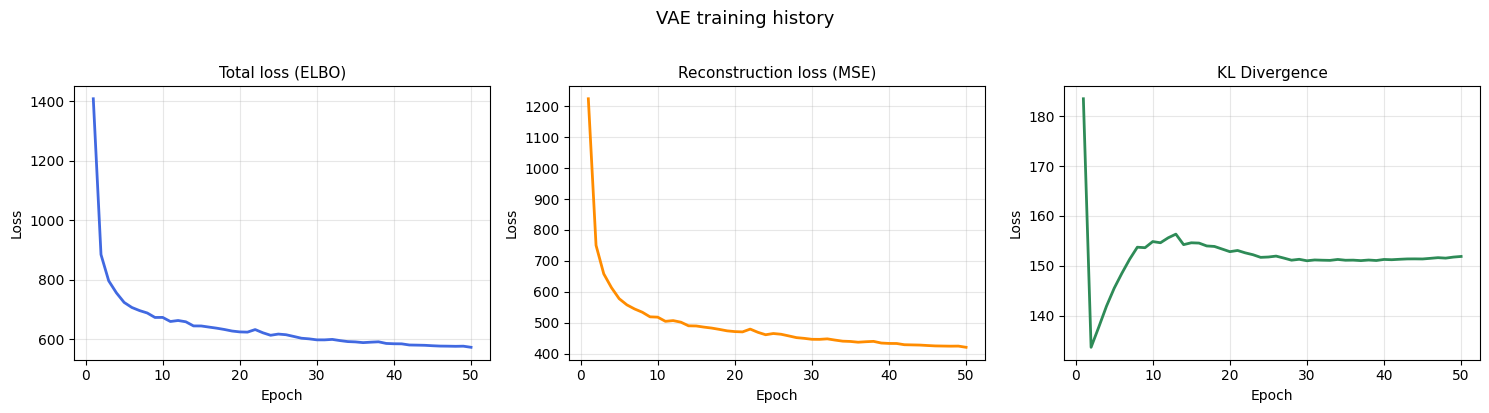

Saved to training_history.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
titles = ["Total loss (ELBO)", "Reconstruction loss (MSE)", "KL Divergence"]
keys   = ["total", "recon", "kl"]
colors = ["royalblue", "darkorange", "seagreen"]

for ax, title, key, color in zip(axes, titles, keys, colors):
    ax.plot(range(1, len(history[key]) + 1), history[key], color=color, linewidth=2)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(alpha=0.3)

plt.suptitle("VAE training history", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("training_history.png", dpi=150, bbox_inches="tight")
plt.show()

# Log the plot as an artifact so it appears in the MLflow run
mlflow.log_artifact("training_history.png")
print("Saved to training_history.png")

## 9. Image generation

To generate new images we sample `z ~ N(0, I)` directly — bypassing the encoder entirely.  
The decoder maps these random vectors into plausible animal images.

Saved to generated_samples.png


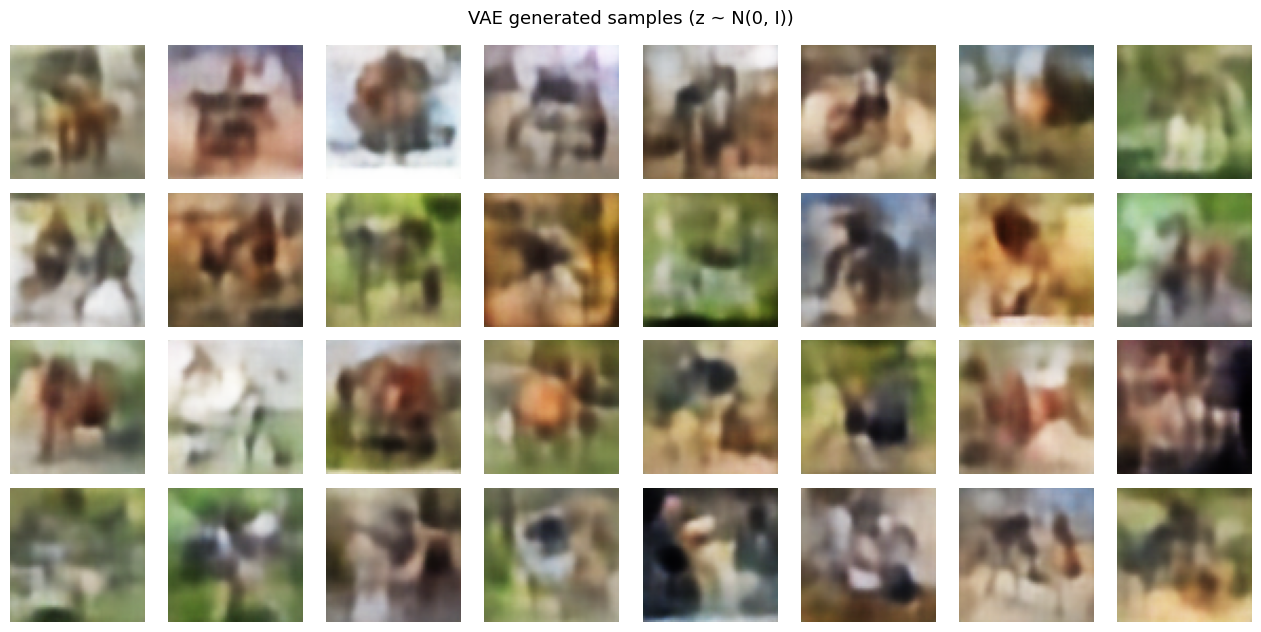

In [11]:
def denormalize(tensor: torch.Tensor) -> torch.Tensor:
    """Revert [-1, 1] normalization to [0, 1] for display."""
    return (tensor * 0.5 + 0.5).clamp(0, 1)


def show_grid(imgs: torch.Tensor, title: str, cols: int = 8, save_as: str = None):
    """
    Display a grid of images.

    Args:
        imgs    : Tensor (N, C, H, W) in the range [0, 1].
        title   : Plot title.
        cols    : Number of columns in the grid.
        save_as : File path to save the figure (optional).
    """
    n = imgs.shape[0]
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.6, rows * 1.6))

    for i, ax in enumerate(axes.flat):
        if i < n:
            ax.imshow(imgs[i].permute(1, 2, 0).cpu().numpy())
        ax.axis("off")

    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    if save_as:
        plt.savefig(save_as, dpi=150, bbox_inches="tight")
        mlflow.log_artifact(save_as)
        print(f"Saved to {save_as}")
    plt.show()


# Generate 32 novel images
model.eval()
generated = denormalize(model.generate(32))
show_grid(generated, "VAE generated samples (z ~ N(0, I))",
          cols=8, save_as="generated_samples.png")

## 10. Reconstruction

We pass real images through the full VAE (encoder → decoder) and compare with the originals.  
Good reconstructions indicate the encoder captured the essential visual features.

Saved to reconstructions.png


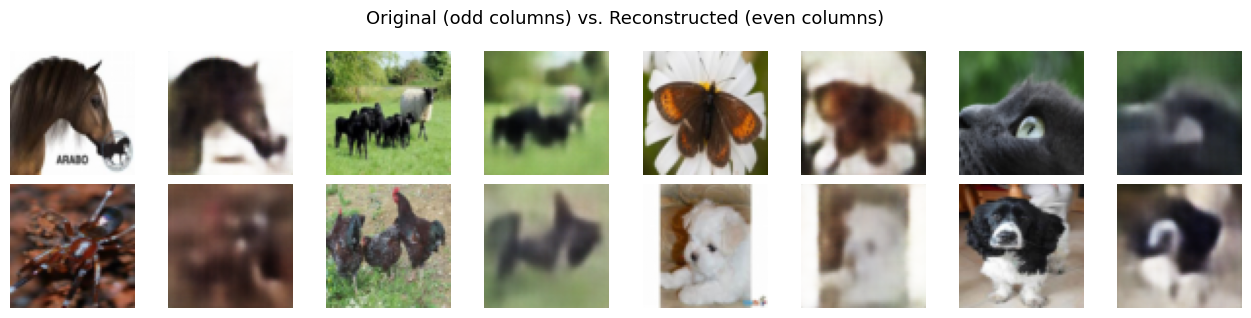

In [12]:
model.eval()
with torch.no_grad():
    sample_batch = next(iter(loader))[:8].to(DEVICE)
    recon_batch, _, _ = model(sample_batch)

originals     = denormalize(sample_batch)
reconstructed = denormalize(recon_batch)

# Interleave originals and reconstructions on the same row
interleaved = torch.stack(
    [img for pair in zip(originals, reconstructed) for img in pair]
)

show_grid(
    interleaved,
    "Original (odd columns) vs. Reconstructed (even columns)",
    cols=8,
    save_as="reconstructions.png",
)

## 11. Latent space interpolation

One of the most compelling properties of a VAE is that its latent space is **continuous and structured**.  
Linearly interpolating between two latent vectors `z₁` and `z₂` produces smooth visual transitions.

$$z(\alpha) = (1-\alpha)\, z_1 + \alpha\, z_2, \quad \alpha \in [0, 1]$$

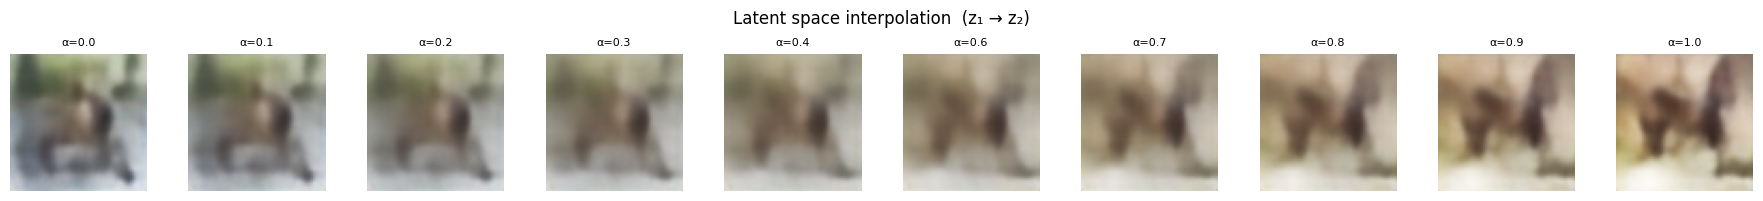

Saved to interpolation.png


In [13]:
def interpolate_latent(model: VAE, steps: int = 10) -> None:
    """
    Generate a sequence of images by linearly interpolating between
    two random points in the latent space.

    Args:
        model : Trained VAE model.
        steps : Number of interpolation steps.
    """
    device = next(model.parameters()).device

    z1 = torch.randn(1, LATENT_DIM, device=device)
    z2 = torch.randn(1, LATENT_DIM, device=device)

    # α sweeps from 0 to 1 across `steps` evenly spaced points
    alphas = torch.linspace(0, 1, steps, device=device)
    zs = torch.stack([(1 - a) * z1 + a * z2 for a in alphas]).squeeze(1)

    with torch.no_grad():
        imgs = denormalize(model.decoder(zs))

    fig, axes = plt.subplots(1, steps, figsize=(steps * 1.8, 2))
    for i, ax in enumerate(axes):
        ax.imshow(imgs[i].permute(1, 2, 0).cpu().numpy())
        ax.set_title(f"α={alphas[i].item():.1f}", fontsize=8)
        ax.axis("off")

    plt.suptitle("Latent space interpolation  (z₁ → z₂)", fontsize=12)
    plt.tight_layout()
    plt.savefig("interpolation.png", dpi=150, bbox_inches="tight")
    mlflow.log_artifact("interpolation.png")
    plt.show()
    print("Saved to interpolation.png")


interpolate_latent(model, steps=10)

## 12. Evaluation — IS & FID

Two standard metrics for generative models:

| Metric | What it measures | Direction |
|---|---|---|
| **Inception Score (IS)** | Quality + diversity of generated images via Inception-v3 class predictions | Higher = better |
| **Fréchet Inception Distance (FID)** | Distance between real and generated distributions in Inception-v3 feature space | Lower = better |

> **Note:** both metrics upsample 64×64 → 299×299 for Inception-v3. Absolute values are less meaningful than the **relative improvement between runs** — use them to compare VAE vs. cVAE.

In [ ]:
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore

N_EVAL = 2048  # images to evaluate — trade-off between accuracy and speed

def to_01(t: torch.Tensor) -> torch.Tensor:
    """Convert [-1, 1] tensor to [0, 1] float."""
    return (t * 0.5 + 0.5).clamp(0, 1)

print(f"Evaluating with {N_EVAL} images (Inception-v3 downloads ~100 MB on first run)...\n")

model.eval()

# ── Inception Score (generated images only) ───────────────────────────────────
is_metric = InceptionScore(normalize=True)
with torch.no_grad():
    for start in range(0, N_EVAL, BATCH_SIZE):
        n = min(BATCH_SIZE, N_EVAL - start)
        z = torch.randn(n, LATENT_DIM, device=DEVICE)
        is_metric.update(to_01(model.decoder(z)).cpu())

is_mean, is_std = is_metric.compute()
print(f"Inception Score : {is_mean:.3f} ± {is_std:.3f}  (higher = better)")

# ── Fréchet Inception Distance (real vs generated) ────────────────────────────
fid_metric = FrechetInceptionDistance(normalize=True)

real_seen = 0
with torch.no_grad():
    for batch in loader:
        fid_metric.update(to_01(batch).cpu(), real=True)
        real_seen += batch.shape[0]
        if real_seen >= N_EVAL:
            break

with torch.no_grad():
    for start in range(0, N_EVAL, BATCH_SIZE):
        n = min(BATCH_SIZE, N_EVAL - start)
        z = torch.randn(n, LATENT_DIM, device=DEVICE)
        fid_metric.update(to_01(model.decoder(z)).cpu(), real=False)

fid_score = fid_metric.compute()
print(f"FID             : {fid_score:.2f}  (lower = better)")

# ── Log to the existing MLflow run ────────────────────────────────────────────
with mlflow.start_run(run_id=run.info.run_id):
    mlflow.log_metrics({"is_mean": float(is_mean), "is_std": float(is_std), "fid": float(fid_score)})
print("\nMetrics logged to MLflow.")